# Study 9: 4-D inference — (length_scale, mu_0, sigma, beta_speaker) via Laplace + VBMC

Extension of `model-study9-vbmc-laplace.ipynb` where the RSA speaker rationality `beta` —
fixed by design at 3 everywhere else — is INFERRED as a fourth parameter:
`phi4 = [log_ls, mu_0, log_sigma, log_beta]` (`inference.run_vbmc_beta` /
`run_vbmc_free_shapes_beta`; lognormal-ish prior around the design value 3).

Identifiability caveat: beta is informed only by the training utterances (one generic per
trained feature per condition), so expect trade-offs with `mu_0` and `sigma` — the slice
diagnostic and pairwise joints below are the check.

Structure:
1. Objective slice along beta (fixed + fitted shapes) at the reference theta
2. 4-D VBMC, fixed linking shapes (`results/study9-vbmc-laplace-beta/posterior.npz`)
3. 4-D VBMC, fitted (profiled) linking shapes (`.../posterior-fitted-shapes.npz`)
4. Posterior marginals (vs the 3-D beta=3 run) + pairwise joints
5. Forward pass at the posterior median
6. GP coherence field per condition at the posterior median (as `plot-gp-coherence-field.ipynb`)

Results are cached — delete a file under `results/study9-vbmc-laplace-beta/` to refit.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")

import sys
sys.path.insert(0, ".")

import json
import numpy as np
import matplotlib.pyplot as plt

import inference as inf   # Laplace + VBMC machinery (sets jax x64; import before other jax users)

MAX_EVALS = 400
RESULTS_DIR = os.path.join('results', 'study9-vbmc-laplace-beta')
os.makedirs(RESULTS_DIR, exist_ok=True)

geom = inf.load_geometry()
J = geom['J']
test_feature_names, test_trait = geom['test_feature_names'], geom['test_trait']
responses_cond, _ = inf.load_responses('../../data/study9.csv')
emp_cond = {c: np.array(responses_cond[c]).mean(0) for c in inf.CONDITIONS}
N_cond   = {c: int(responses_cond[c].shape[0]) for c in inf.CONDITIONS}
for c in inf.CONDITIONS:
    print(f"  {c:<14}: {N_cond[c]} participants  mean rating={np.array(responses_cond[c]).mean():.3f}")

  diet          : 101 participants  mean rating=0.528
  personality   : 101 participants  mean rating=0.555
  physical      : 101 participants  mean rating=0.593
  heterogeneous : 99 participants  mean rating=0.543


## 1. Objective slice along beta

Summed `log Z` as a function of `beta_speaker` with `(ls, mu_0, sigma)` at the reference values,
under both fixed and fitted linking shapes. Checks there is curvature in the beta direction at
all before trusting the 4-D fit.

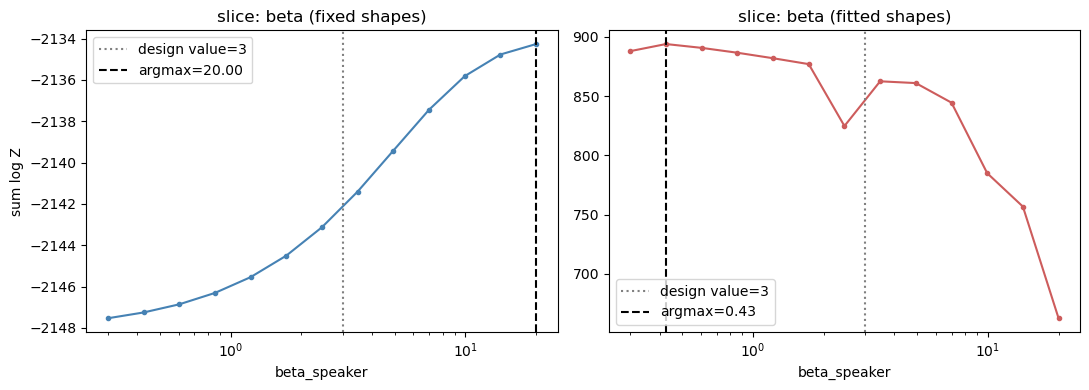

In [2]:
cond_data = inf.prepare_all_conditions(geom, responses_cond)   # fixed default linking shapes
REF_LS, REF_MU, REF_SIGMA = 0.4, 0.0, 1.5

beta_grid = np.geomspace(0.3, 20.0, 13)
ll_beta   = np.array([inf.total_log_lik(cond_data, REF_LS, REF_MU, REF_SIGMA, beta_speaker=b)
                      for b in beta_grid])
ll_beta_f = np.array([inf.total_log_lik_free_shapes(geom, responses_cond, REF_LS, REF_MU, REF_SIGMA,
                                                    beta_speaker=b) for b in beta_grid])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, ll, ttl, col in [(axes[0], ll_beta, 'fixed shapes', 'steelblue'),
                         (axes[1], ll_beta_f, 'fitted shapes', 'indianred')]:
    ax.plot(beta_grid, ll, '-o', ms=3, color=col)
    ax.axvline(inf.BETA_SPEAKER, color='gray', ls=':', label=f'design value={inf.BETA_SPEAKER:g}')
    ax.axvline(beta_grid[np.argmax(ll)], color='k', ls='--',
               label=f'argmax={beta_grid[np.argmax(ll)]:.2f}')
    ax.set_xscale('log'); ax.set_xlabel('beta_speaker'); ax.legend()
    ax.set_title(f'slice: beta ({ttl})')
axes[0].set_ylabel('sum log Z')
plt.tight_layout(); plt.show()

## 2. 4-D VBMC, FIXED linking shapes

Cached to `results/study9-vbmc-laplace-beta/posterior.npz` (adds `beta_samples` to the usual keys).

In [3]:
SAMPLE_KEYS = ('ls_samples', 'mu0_samples', 'sigma_samples', 'beta_samples')

def load_or_fit(path, fit_fn):
    if os.path.exists(path):
        z = np.load(path, allow_pickle=True)
        fit = {k: z[k] for k in SAMPLE_KEYS}
        fit.update(json.loads(str(z['meta'])))
        print(f"loaded cached posterior from {path}  ({fit['convergence_status']})")
    else:
        fit = fit_fn()
        np.savez_compressed(path, **{k: fit[k] for k in SAMPLE_KEYS},
                            meta=json.dumps({k: fit[k] for k in ('elbo', 'func_count',
                                                                 'convergence_status', 'runtime_s')}))
        print(f"saved posterior to {path}")
    return fit

fit = load_or_fit(os.path.join(RESULTS_DIR, 'posterior.npz'),
                  lambda: inf.run_vbmc_beta(cond_data, max_evals=MAX_EVALS))

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Reshaping x0 to row vector.


Reshaping lower bounds to (1, 4).


Reshaping upper bounds to (1, 4).


Reshaping plausible lower bounds to (1, 4).


...

    33        175       -1994.43         0.13         0.00       13      0.237     stable


   inf        175       -1994.41         0.13         0.00       50      0.237     finalize


Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: -1994.415 +/-0.134.


saved posterior to results/study9-vbmc-laplace-beta/posterior.npz


## 3. 4-D VBMC, FITTED (profiled) linking shapes

Same treatment as section 7a of the main notebook; beta now also enters the ratings-free
coherence mode that the per-feature shape fit conditions on. Cached to
`results/study9-vbmc-laplace-beta/posterior-fitted-shapes.npz`.

In [4]:
fit_f = load_or_fit(os.path.join(RESULTS_DIR, 'posterior-fitted-shapes.npz'),
                    lambda: inf.run_vbmc_free_shapes_beta(geom, responses_cond, max_evals=MAX_EVALS))

Reshaping x0 to row vector.


Reshaping lower bounds to (1, 4).


Reshaping upper bounds to (1, 4).


Reshaping plausible lower bounds to (1, 4).


Reshaping plausible upper bounds to (1, 4).


...

    57        290         908.32         0.35         0.01       16       0.31     stable


   inf        290         908.35         0.35         0.01       50       0.31     finalize


Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: 908.350 +/-0.347.


saved posterior to results/study9-vbmc-laplace-beta/posterior-fitted-shapes.npz


## 4. Posterior marginals + pairwise joints

Marginals for the shared three parameters are overlaid on the 3-D fitted-shapes posterior from
`results/study9-vbmc-laplace/` (where beta was fixed at 3), to show what freeing beta changes.

fixed shapes : convergence=probable  (evals 175, ELBO -1994.4)
fitted shapes: convergence=probable  (evals 290, ELBO 908.4)
param                       4-D fixed shapes             4-D fitted shapes           3-D fitted (beta=3)
length_scale            0.031 [0.030, 0.035]          0.205 [0.162, 0.278]          0.264 [0.197, 0.346]
mu_0                    0.514 [0.226, 0.803]       -0.397 [-0.759, -0.045]        -0.014 [-0.156, 0.151]
sigma                   1.012 [0.824, 1.249]          0.782 [0.567, 1.003]          0.570 [0.430, 0.733]
beta_speaker          24.126 [6.882, 29.687]        16.035 [7.017, 27.002]                  (fixed at 3)


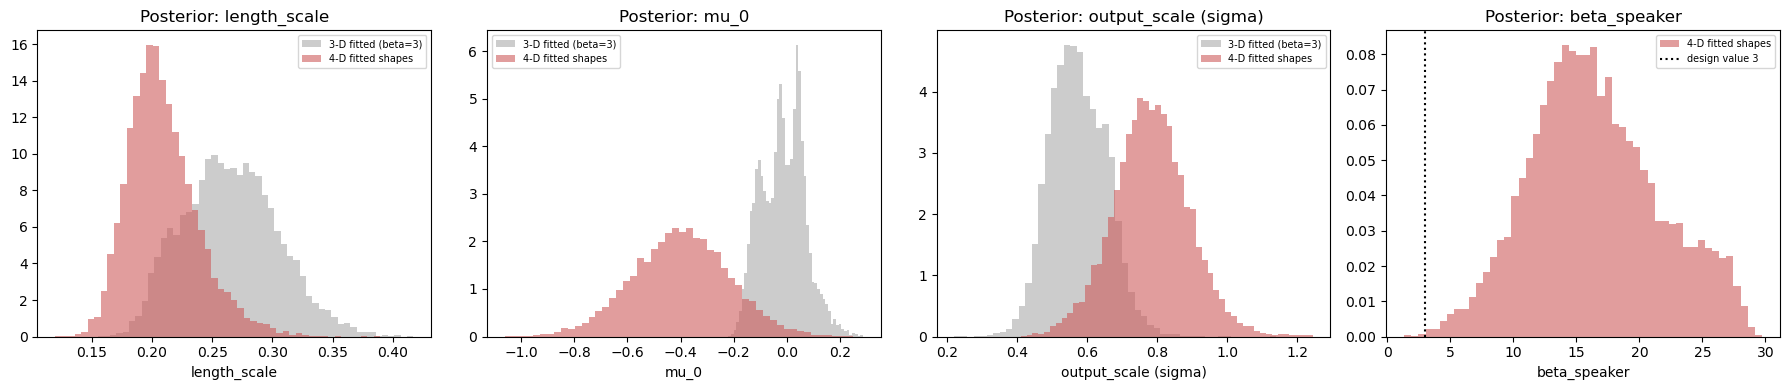

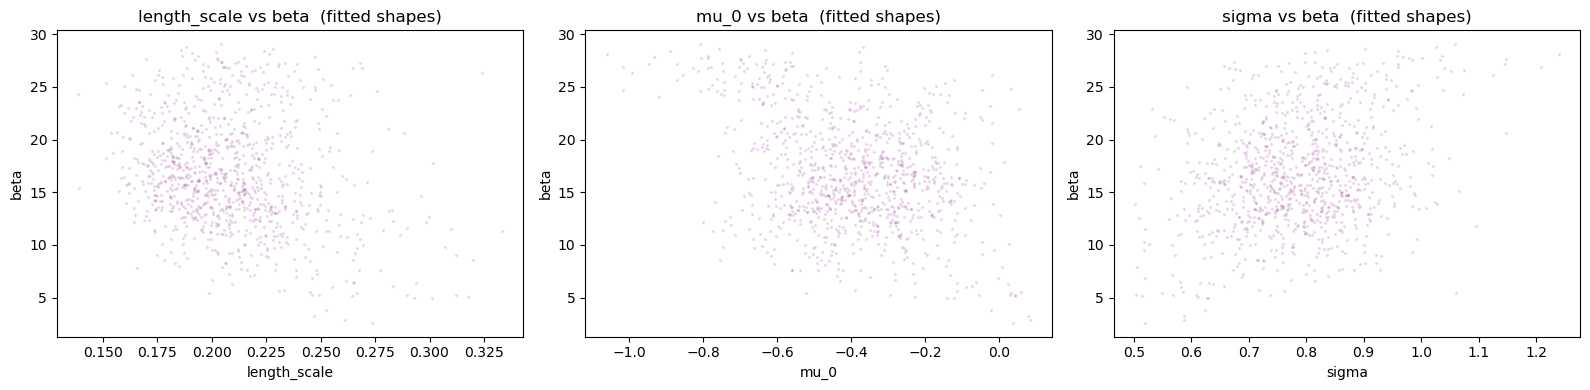

In [5]:
z3 = np.load(os.path.join('results', 'study9-vbmc-laplace', 'posterior-fitted-shapes.npz'),
             allow_pickle=True)

for lbl, f in [('fixed shapes ', fit), ('fitted shapes', fit_f)]:
    print(f"{lbl}: convergence={f['convergence_status']}  (evals {f['func_count']}, ELBO {f['elbo']:.1f})")
print(f"{'param':<14}{'4-D fixed shapes':>30}{'4-D fitted shapes':>30}{'3-D fitted (beta=3)':>30}")
def fmt(s): return f"{np.median(s):7.3f} [{np.percentile(s,2.5):.3f}, {np.percentile(s,97.5):.3f}]"
for name, key in [('length_scale', 'ls_samples'), ('mu_0', 'mu0_samples'),
                  ('sigma', 'sigma_samples'), ('beta_speaker', 'beta_samples')]:
    ref = fmt(z3[key]) if key in z3 else '(fixed at 3)'
    print(f"{name:<14}{fmt(fit[key]):>30}{fmt(fit_f[key]):>30}{ref:>30}")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, key, name in zip(axes, ['ls_samples', 'mu0_samples', 'sigma_samples', 'beta_samples'],
                         ['length_scale', 'mu_0', 'output_scale (sigma)', 'beta_speaker']):
    if key in z3:
        ax.hist(z3[key], bins=50, density=True, color='gray', alpha=0.4, label='3-D fitted (beta=3)')
    ax.hist(fit_f[key], bins=50, density=True, color='indianred', alpha=0.6, label='4-D fitted shapes')
    if key == 'beta_samples':
        ax.axvline(inf.BETA_SPEAKER, color='k', ls=':', label='design value 3')
    ax.set_xlabel(name); ax.set_title(f'Posterior: {name}'); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

pairs = [('ls_samples', 'beta_samples', 'length_scale', 'beta'),
         ('mu0_samples', 'beta_samples', 'mu_0', 'beta'),
         ('sigma_samples', 'beta_samples', 'sigma', 'beta')]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (kx, ky, xn, yn) in zip(axes, pairs):
    ax.scatter(fit_f[kx][::10], fit_f[ky][::10], alpha=0.1, s=2, color='purple')
    ax.set_xlabel(xn); ax.set_ylabel(yn); ax.set_title(f'{xn} vs {yn}  (fitted shapes)')
plt.tight_layout(); plt.show()

## 5. Forward pass at the posterior median (fitted shapes)

Fitted per-feature shapes at the 4-D posterior median, then predicted vs empirical prevalence
per condition (as section 7c of the main notebook).

Posterior median: ls=0.205, mu_0=-0.397, sigma=0.782, beta=16.035


saved fitted shapes to results/study9-vbmc-laplace-beta/fitted-link-shapes.csv (+ .npz with theta)


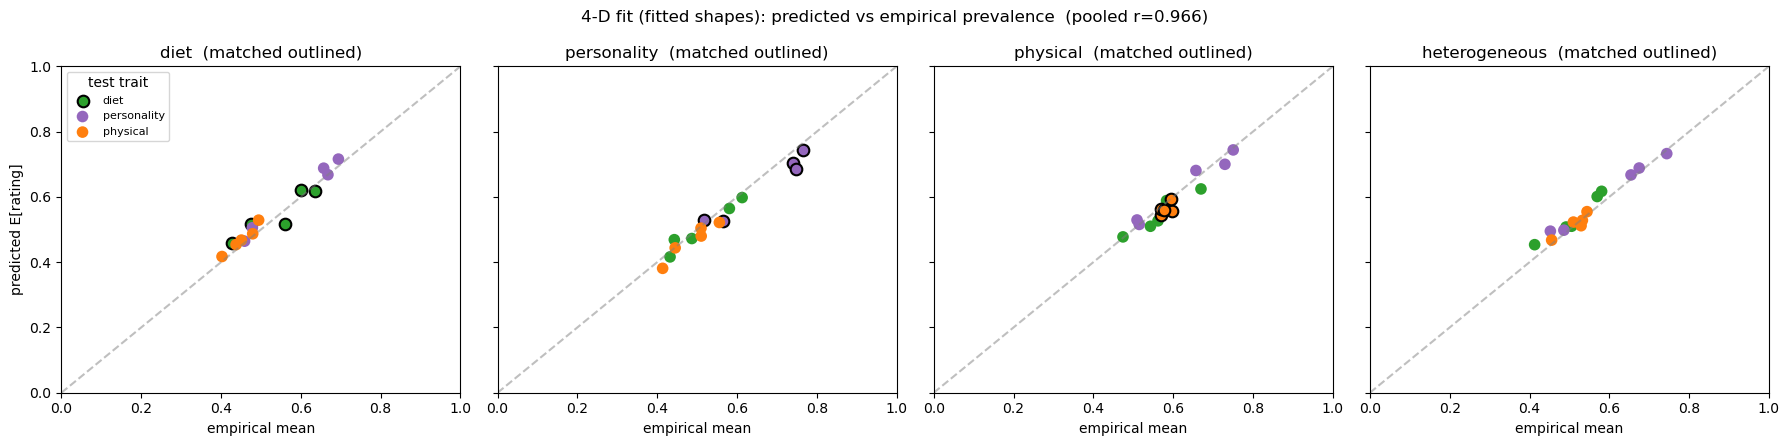

In [6]:
LS_B, MU_B, SIG_B, BETA_B = (float(np.median(fit_f['ls_samples'])), float(np.median(fit_f['mu0_samples'])),
                             float(np.median(fit_f['sigma_samples'])), float(np.median(fit_f['beta_samples'])))
print(f"Posterior median: ls={LS_B:.3f}, mu_0={MU_B:.3f}, sigma={SIG_B:.3f}, beta={BETA_B:.3f}")

_, shapes_f, cond_data_f = inf.total_log_lik_free_shapes(
    geom, responses_cond, LS_B, MU_B, SIG_B, beta_speaker=BETA_B, return_shapes=True)
mean_kl_f  = shapes_f[:, 0] / (shapes_f[:, 0] + shapes_f[:, 1])
mean_nkl_f = shapes_f[:, 2] / (shapes_f[:, 2] + shapes_f[:, 3])

np.savez_compressed(os.path.join(RESULTS_DIR, 'fitted-link-shapes.npz'),
                    shapes=shapes_f, feature_names=np.array(test_feature_names),
                    theta=np.array([LS_B, MU_B, SIG_B, BETA_B]))
import csv as _csv
SHAPES_CSV = os.path.join(RESULTS_DIR, 'fitted-link-shapes.csv')
with open(SHAPES_CSV, 'w', newline='') as f:
    w = _csv.writer(f)
    w.writerow(['feature', 'trait', 'a_kl', 'b_kl', 'a_nkl', 'b_nkl', 'mean_kl', 'mean_nkl'])
    for j, name in enumerate(test_feature_names):
        w.writerow([name, test_trait[j], *[f'{v:.4f}' for v in shapes_f[j]],
                    f'{mean_kl_f[j]:.4f}', f'{mean_nkl_f[j]:.4f}'])
print(f'saved fitted shapes to {SHAPES_CSV} (+ .npz with theta)')

traits = np.array(test_trait)
tcolor = {'diet': 'tab:green', 'personality': 'tab:purple', 'physical': 'tab:orange'}

pz1_mode_f, pred_cond_f = {}, {}
for c in inf.CONDITIONS:
    _, y_hat, ok = inf.laplace_log_Z(cond_data_f[c], LS_B, MU_B, SIG_B, beta_speaker=BETA_B)
    pz1_mode_f[c] = 1.0 / (1.0 + np.exp(-y_hat[:J]))
    pred_cond_f[c] = pz1_mode_f[c]*mean_kl_f + (1-pz1_mode_f[c])*mean_nkl_f
    if not ok:
        print(f"  warning: {c} Laplace mode not cleanly converged")

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharex=True, sharey=True)
for ax, c in zip(axes, inf.CONDITIONS):
    for tr in tcolor:
        m = traits == tr
        ax.scatter(emp_cond[c][m], pred_cond_f[c][m], s=70, color=tcolor[tr],
                   edgecolor=('k' if tr == c else 'none'), linewidth=1.5, label=tr)
    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"{c}  (matched outlined)"); ax.set_xlabel('empirical mean')
axes[0].set_ylabel("predicted E[rating]"); axes[0].legend(fontsize=8, title='test trait')
r_all_f = np.corrcoef(np.concatenate([emp_cond[c] for c in inf.CONDITIONS]),
                      np.concatenate([pred_cond_f[c] for c in inf.CONDITIONS]))[0, 1]
fig.suptitle(f'4-D fit (fitted shapes): predicted vs empirical prevalence  (pooled r={r_all_f:.3f})')
plt.tight_layout(); plt.show()

## 6. GP coherence field per condition at the posterior median

Same visualization as `plot-gp-coherence-field.ipynb`: contours are the ratings-free
GP-conditional `P(kind-linked)` given each condition's trained region, at the 4-D
posterior-median theta (including the fitted beta, which enters the speaker term of the
coherence mode). Test points are colored by empirical mean rating on the same color scale.

saved results/study9-vbmc-laplace-beta/gp-coherence-field.png


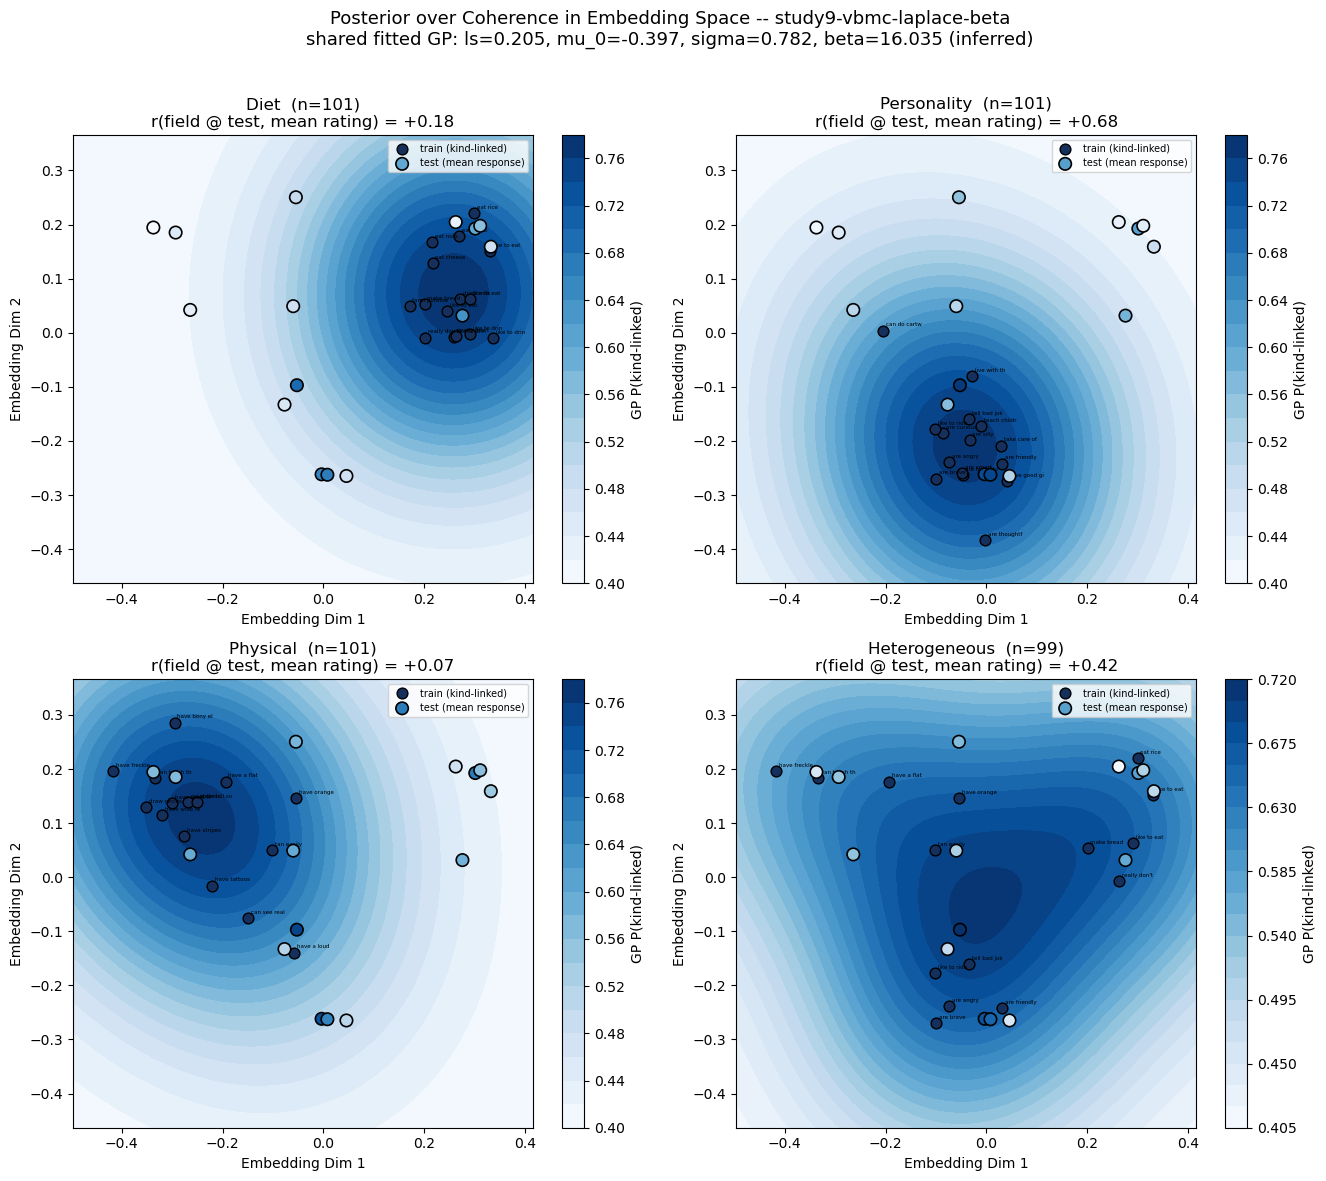

In [7]:
all_x = np.vstack([np.array(geom['x_test'])] + [np.array(geom['x_train_cond'][c]) for c in inf.CONDITIONS])
pad = 0.08
(x_lo, y_lo), (x_hi, y_hi) = all_x.min(0) - pad, all_x.max(0) + pad
gx, gy = np.meshgrid(np.linspace(x_lo, x_hi, 80), np.linspace(y_lo, y_hi, 80))
X_grid = np.column_stack([gx.ravel(), gy.ravel()])
x_test_np = np.array(geom['x_test'])

fig, axes = plt.subplots(2, 2, figsize=(13.5, 12))
for ax, c in zip(axes.ravel(), inf.CONDITIONS):
    field    = inf.gp_coherence_field(geom, c, LS_B, MU_B, SIG_B, X_grid,
                                      beta_speaker=BETA_B).reshape(gx.shape)
    pz1_test = inf.gp_coherence_field(geom, c, LS_B, MU_B, SIG_B, x_test_np, beta_speaker=BETA_B)
    cs = ax.contourf(gx, gy, field, levels=20, cmap='Blues')
    cb = fig.colorbar(cs, ax=ax); cb.set_label('GP P(kind-linked)')

    x_tr = np.array(geom['x_train_cond'][c])
    ax.scatter(x_tr[:, 0], x_tr[:, 1], s=60, color='#16305e', edgecolor='k',
               zorder=3, label='train (kind-linked)')
    for (xx, yy), nm in zip(x_tr, geom['train_names_cond'][c]):
        ax.annotate(nm[:12], (xx, yy), fontsize=4, xytext=(2, 3), textcoords='offset points')
    ax.scatter(x_test_np[:, 0], x_test_np[:, 1], s=80, c=emp_cond[c], cmap='Blues', norm=cs.norm,
               edgecolor='k', linewidth=1.2, zorder=3, label='test (mean response)')

    r = np.corrcoef(pz1_test, emp_cond[c])[0, 1]
    ax.set_title(f"{c.capitalize()}  (n={N_cond[c]})\nr(field @ test, mean rating) = {r:+.2f}")
    ax.set_xlabel('Embedding Dim 1'); ax.set_ylabel('Embedding Dim 2')
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle(f"Posterior over Coherence in Embedding Space -- study9-vbmc-laplace-beta\n"
             f"shared fitted GP: ls={LS_B:.3f}, mu_0={MU_B:+.3f}, sigma={SIG_B:.3f}, "
             f"beta={BETA_B:.3f} (inferred)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.965])
out_png = os.path.join(RESULTS_DIR, 'gp-coherence-field.png')
fig.savefig(out_png, dpi=150, bbox_inches='tight')
print('saved', out_png)
plt.show()